In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from google.cloud import storage
import io
from orchestrator import Orchestrator
import cProfile
import asyncio
import pstats
import io
import sys
sys.path.append("..")

from creds import MAPPER_URL, REDUCER_URL

In [3]:
bucket_name = "jack-fall2024"


In [4]:
# Generate Matrices
Matrix_A = np.random.randint(0, 10, (10, 10))  
Matrix_B = np.random.randint(0, 10, (10, 10)) 

# Initialize Google Cloud Storage client
client = storage.Client()
bucket = client.bucket(bucket_name)

def upload_matrix_to_gcs(matrix, matrix_name):
    matrix_bytes = io.BytesIO()
    np.save(matrix_bytes, matrix)
    matrix_bytes.seek(0) 

    blob = bucket.blob(f"{matrix_name}.npy")

    blob.upload_from_file(matrix_bytes, content_type='application/octet-stream')
    print(f"Uploaded {matrix_name} to {bucket_name}.")

# Upload both matrices
upload_matrix_to_gcs(Matrix_A, "Matrix_A")
upload_matrix_to_gcs(Matrix_B, "Matrix_B")




Uploaded Matrix_A to jack-fall2024.
Uploaded Matrix_B to jack-fall2024.


In [5]:
print(Matrix_A)

[[9 9 4 4 8 8 9 7 9 7]
 [7 7 0 1 4 2 8 4 9 5]
 [6 3 3 4 3 5 2 7 0 7]
 [1 8 6 3 1 5 1 0 8 1]
 [1 2 4 0 9 9 4 7 0 8]
 [2 8 7 5 6 7 8 4 5 6]
 [4 0 0 0 5 5 7 7 2 0]
 [8 1 1 9 6 6 7 7 9 9]
 [8 4 5 6 1 9 3 8 5 2]
 [4 0 6 0 1 7 8 4 9 0]]


In [6]:
print(Matrix_B)

[[6 9 4 7 6 7 0 3 6 6]
 [8 9 6 7 5 4 1 0 6 5]
 [6 7 2 7 5 1 3 6 9 4]
 [5 2 4 8 5 6 2 3 9 1]
 [2 7 3 7 9 3 5 9 9 3]
 [5 6 7 4 4 0 9 3 0 3]
 [0 3 3 0 3 7 5 3 1 4]
 [5 2 7 2 8 6 0 9 7 1]
 [2 6 7 6 1 8 9 0 1 8]
 [9 8 9 2 1 6 0 2 4 3]]


In [7]:

print(np.matmul(Matrix_A, Matrix_B))

[[342 453 396 356 342 370 267 263 347 303]
 [204 294 260 214 196 277 168 136 194 219]
 [227 237 226 185 202 188  90 173 223 127]
 [173 225 182 206 132 143 159  77 157 162]
 [216 262 247 178 229 164 160 226 220 133]
 [274 343 298 279 261 257 217 210 287 218]
 [ 98 148 150 109 168 150 123 156 127 105]
 [283 345 350 294 276 350 222 231 299 236]
 [255 287 274 260 248 237 177 193 252 190]
 [135 213 195 167 156 189 207 138 132 180]]


In [8]:

block_size = 15
orch = Orchestrator(Matrix_A, Matrix_B, block_size, MAPPER_URL, REDUCER_URL, bucket_name)

start_time = time.time() 
map_result, _, _ = await orch.orchestrate_matrix_multiplication()
name = 'final_matrix.npy'
orch.save_to_bucket(map_result, name)
print(map_result)
print(time.time() - start_time)

[[342. 453. 396. 356. 342. 370. 267. 263. 347. 303.]
 [204. 294. 260. 214. 196. 277. 168. 136. 194. 219.]
 [227. 237. 226. 185. 202. 188.  90. 173. 223. 127.]
 [173. 225. 182. 206. 132. 143. 159.  77. 157. 162.]
 [216. 262. 247. 178. 229. 164. 160. 226. 220. 133.]
 [274. 343. 298. 279. 261. 257. 217. 210. 287. 218.]
 [ 98. 148. 150. 109. 168. 150. 123. 156. 127. 105.]
 [283. 345. 350. 294. 276. 350. 222. 231. 299. 236.]
 [255. 287. 274. 260. 248. 237. 177. 193. 252. 190.]
 [135. 213. 195. 167. 156. 189. 207. 138. 132. 180.]]
1.3841261863708496


In [9]:
dim = 50
blocksizes = [1, 2, 5, 10, 15, 20, 25, 50]
results = []
for blocksize in blocksizes:
    Matrix_A = np.random.randint(0, 10, (dim, dim))
    Matrix_B = np.random.randint(0, 10, (dim, dim))


    orch = Orchestrator(Matrix_A, Matrix_B, blocksize, MAPPER_URL, REDUCER_URL, bucket_name)

    start_time = time.time()
    map_result, _, _ = await orch.orchestrate_matrix_multiplication()
    results.append(time.time() - start_time)

[57.747655153274536, 29.351958751678467, 10.79257845878601, 5.56985068321228, 4.607471466064453, 3.6665427684783936, 2.712141275405884, 1.5297515392303467]


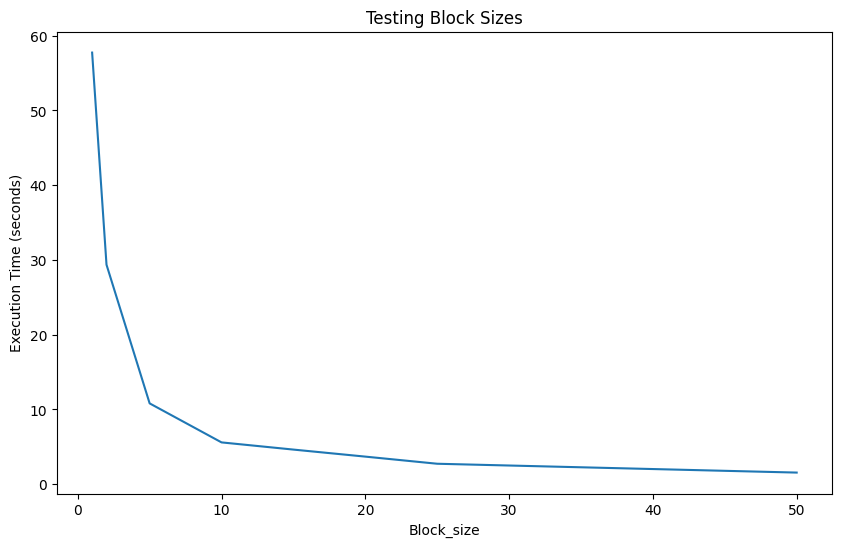

In [10]:

print(results)
plt.figure(figsize=(10, 6))
plt.plot(blocksizes, results)
plt.xlabel('Block_size')
plt.ylabel('Execution Time (seconds)')
plt.title('Testing Block Sizes')
plt.show()

In [11]:
numpy_times = []
mapreduce_times = []
dimensions = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
blocksize = 15
for dim in dimensions:
    # Create random matrices
    Matrix_A = np.random.randint(0, 10, (dim, dim))
    Matrix_B = np.random.randint(0, 10, (dim, dim))
    
    start_time = time.time()
    np.matmul(Matrix_A, Matrix_B)
    numpy_times.append(time.time() - start_time)

    orch = Orchestrator(Matrix_A, Matrix_B, blocksize, MAPPER_URL, REDUCER_URL, bucket_name)

    start_time = time.time()
    map_result, _, _ = await orch.orchestrate_matrix_multiplication()

    mapreduce_times.append(time.time() - start_time)



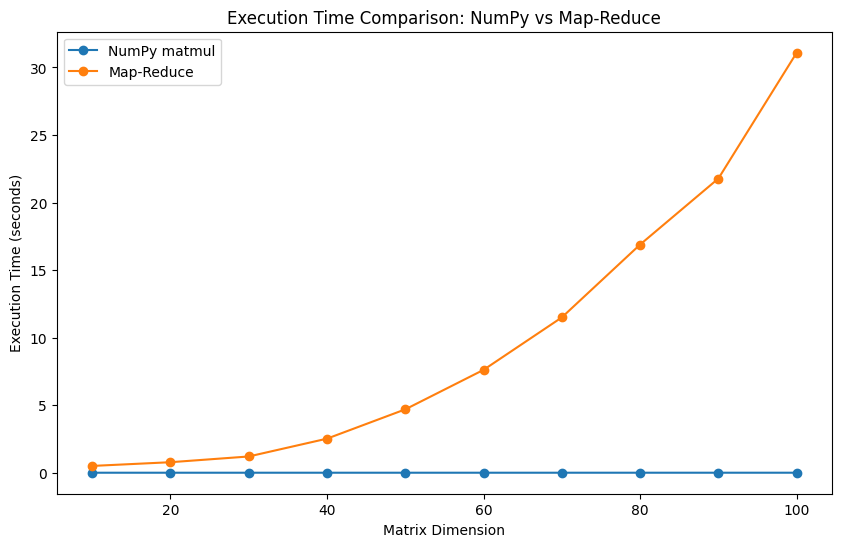

In [12]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(dimensions, numpy_times, label='NumPy matmul', marker='o')
plt.plot(dimensions, mapreduce_times, label='Map-Reduce', marker='o')
plt.xlabel('Matrix Dimension')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison: NumPy vs Map-Reduce')
plt.legend()
plt.show()

In [13]:
numpy_times = []
map_times = []
reduce_times = []
dimensions = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
blocksize = 15
for dim in dimensions:
    # Create random matrices
    Matrix_A = np.random.randint(0, 10, (dim, dim))
    Matrix_B = np.random.randint(0, 10, (dim, dim))


    orch = Orchestrator(Matrix_A, Matrix_B, blocksize, MAPPER_URL, REDUCER_URL, bucket_name)

    _, map_result, reduce_result = await orch.orchestrate_matrix_multiplication()

    map_times.append(map_result)
    reduce_times.append(reduce_result)



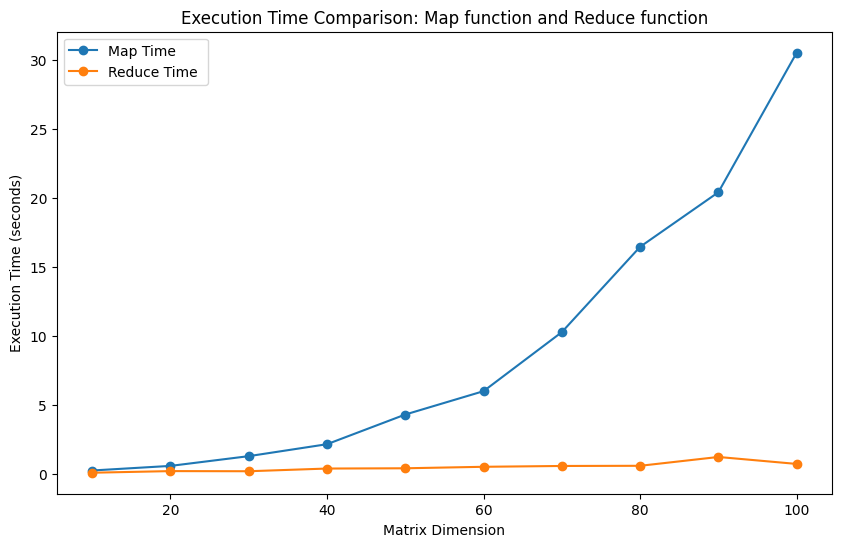

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(dimensions, map_times, label='Map Time', marker='o')
plt.plot(dimensions, reduce_times, label='Reduce Time ', marker='o')
plt.xlabel('Matrix Dimension')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison: Map function and Reduce function')
plt.legend()
plt.show()

In [15]:
dim = 200
block_size = 15

Matrix_A = np.random.randint(0, 10, (dim, dim))
Matrix_B = np.random.randint(0, 10, (dim, dim))

orch = Orchestrator(Matrix_A, Matrix_B, block_size, MAPPER_URL, REDUCER_URL, bucket_name)

start_time = time.time() 
map_result, _, _ = await orch.orchestrate_matrix_multiplication()
print(time.time() - start_time)

223.32094812393188
